## Importação das bibliotecas e da base

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("MetaPosts.csv")



-----------------------

## Validação da base

Análise das colunas

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   rede_social           583 non-null    object 
 1   marca                 583 non-null    object 
 2   ano                   583 non-null    int64  
 3   mes                   583 non-null    int64  
 4   data_hora_criacao     583 non-null    object 
 5   dia_da_semana         583 non-null    object 
 6   link                  583 non-null    object 
 7   url_imagem            583 non-null    object 
 8   legenda               583 non-null    object 
 9   tipo                  583 non-null    object 
 10  alcance_organico      292 non-null    float64
 11  alcance_pago          292 non-null    float64
 12  alcance_total         583 non-null    int64  
 13  curtidas_e_reacoes    583 non-null    int64  
 14  comentarios           583 non-null    int64  
 15  compartilhamentos     5

Quantidade dos valores nulo de cada variável

In [3]:
df.isnull().sum()

rede_social               0
marca                     0
ano                       0
mes                       0
data_hora_criacao         0
dia_da_semana             0
link                      0
url_imagem                0
legenda                   0
tipo                      0
alcance_organico        291
alcance_pago            291
alcance_total             0
curtidas_e_reacoes        0
comentarios               0
compartilhamentos         0
cliques                   0
salvos                    0
views                   290
impressoes_organicas      0
impressoes_pagas          0
impressoes_totais         0
envolvimento              0
taxa_de_engajamento       0
dtype: int64

Quase metade dos dados de views, alcance orgânico e pago são nulos

In [4]:
df.duplicated().sum()

np.int64(0)

Não tem nenhuma linha duplicada

In [5]:
df["salvos"].value_counts()

salvos
0      369
1       70
2       40
3       34
5       18
4       14
6        8
7        6
8        5
14       2
9        2
16       2
29       1
174      1
40       1
17       1
109      1
25       1
28       1
23       1
19       1
114      1
56       1
13       1
18       1
Name: count, dtype: int64

Grande número de 0

In [6]:
df["alcance_organico"].value_counts()

alcance_organico
1777.0    3
2648.0    3
1034.0    2
1961.0    2
849.0     2
         ..
1770.0    1
1657.0    1
1756.0    1
1872.0    1
3329.0    1
Name: count, Length: 266, dtype: int64

Números normais porém com metade dos dados sendo nulos

In [7]:
df["alcance_pago"].value_counts()

alcance_pago
0.0    292
Name: count, dtype: int64

Metade dos dados de alcance pago são nulos e a outra apenas 0.0

In [8]:
df["views"].value_counts()

views
0.0        292
22614.0      1
Name: count, dtype: int64

Apenas uma linha das views é diferente de 0

In [9]:
df["impressoes_pagas"].value_counts()

impressoes_pagas
0         582
144817      1
Name: count, dtype: int64

Apenas uma linha das impressões pagas é diferente de 0

In [10]:
df.head()

,rede_social,marca,ano,mes,data_hora_criacao,dia_da_semana,link,url_imagem,legenda,tipo,...,comentarios,compartilhamentos,cliques,salvos,views,impressoes_organicas,impressoes_pagas,impressoes_totais,envolvimento,taxa_de_engajamento
0,Instagram,B Braun,2026,7,03/07/2026 12:01:47,Sexta-Feira,https://www.instagram.com/p/DaVHjZqjF3u,https://storage.googleapis.com/brv-valhalla-da...,E se você pudesse conhecer a tecnologia OMNI a...,reels,...,5,27,0,1,0.0,2571,0,2571,89,"0,0520163647"
1,Facebook,B Braun,2026,7,03/07/2026 12:01:06,Sexta-Feira,https://www.facebook.com/reel/2536486383534747/,https://storage.googleapis.com/brv-valhalla-da...,E se você pudesse conhecer a tecnologia OMNI a...,reels,...,0,0,0,0,NaN,74,0,75,4,"0,05797101449"
2,Facebook,B Braun,2026,7,02/07/2026 13:28:01,Quinta-Feira,https://www.facebook.com/reel/1610329023941411/,https://storage.googleapis.com/brv-valhalla-da...,Um hospital é movido por pessoas. Pessoas que ...,reels,...,0,0,1,0,NaN,219,0,219,5,"0,02380952381"
3,Instagram,B Braun,2026,7,02/07/2026 13:26:15,Quinta-Feira,https://www.instagram.com/p/DaSsbGZj7Oc,https://storage.googleapis.com/brv-valhalla-da...,Um hospital é movido por pessoas. Pessoas que ...,reels,...,0,6,0,0,0.0,1449,0,1449,64,"0,06189555126"
4,Instagram,B Braun,2026,6,29/06/2026 12:00:16,Segunda-Feira,https://www.instagram.com/p/DaK0SiaiMVL,https://storage.googleapis.com/brv-valhalla-da...,Higienizar as mãos é um protocolo de segurança...,carrossel,...,0,6,0,1,0.0,1536,0,1536,43,"0,05826558266"


-----------------------

## Tratamanto de variáveis 

Tranformar a taxa de engajamento para float para conseguir fazer os cálculos com ela

In [11]:

def obj_to_float(x):
    tranforma = float(x.replace(' ','')
                .replace(',', '.'))
    return tranforma

df['taxa_de_engajamento'] = df['taxa_de_engajamento'].apply(obj_to_float)


Transformar a data de object para datetime

In [12]:
df["data_hora_criacao"] = pd.to_datetime(
    df["data_hora_criacao"],
    format="%d/%m/%Y %H:%M:%S"
)

Excluir colunas que não tem dados suficientes

In [13]:
df = df.drop(columns=['views', 'impressoes_pagas', 'alcance_pago'])

Completar os valores nulos de alcance orgânico com a mediana, foi escolhida a mediana por conta da presença de outliers, assim com a mediana pega o número do meio

In [14]:
df['alcance_organico'] = df['alcance_organico'].fillna(df['alcance_organico'].median())

-----------------------

## Validação pós tratamento da base

In [15]:
df.isnull().sum()

rede_social             0
marca                   0
ano                     0
mes                     0
data_hora_criacao       0
dia_da_semana           0
link                    0
url_imagem              0
legenda                 0
tipo                    0
alcance_organico        0
alcance_total           0
curtidas_e_reacoes      0
comentarios             0
compartilhamentos       0
cliques                 0
salvos                  0
impressoes_organicas    0
impressoes_totais       0
envolvimento            0
taxa_de_engajamento     0
dtype: int64

Nenhum valor nulo

In [16]:
df["alcance_organico"].value_counts()

alcance_organico
1965.0    291
2648.0      3
1777.0      3
3860.0      2
1140.0      2
         ... 
3140.0      1
1279.0      1
3370.0      1
2535.0      1
1770.0      1
Name: count, Length: 267, dtype: int64

Valores nulo substituídos pela mediana

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   rede_social           583 non-null    object        
 1   marca                 583 non-null    object        
 2   ano                   583 non-null    int64         
 3   mes                   583 non-null    int64         
 4   data_hora_criacao     583 non-null    datetime64[ns]
 5   dia_da_semana         583 non-null    object        
 6   link                  583 non-null    object        
 7   url_imagem            583 non-null    object        
 8   legenda               583 non-null    object        
 9   tipo                  583 non-null    object        
 10  alcance_organico      583 non-null    float64       
 11  alcance_total         583 non-null    int64         
 12  curtidas_e_reacoes    583 non-null    int64         
 13  comentarios         

-Data foi para datetime

-Colunas com muitos valores nulo excluídas

-Taxa de engajamento tipo float64 agora

-----------------------

## Análise

**Análise dos números das métricas utilizadas**

In [18]:
df.describe()

,ano,mes,data_hora_criacao,alcance_organico,alcance_total,curtidas_e_reacoes,comentarios,compartilhamentos,cliques,salvos,impressoes_organicas,impressoes_totais,envolvimento,taxa_de_engajamento
count,583.000000,583.000000,583,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,2025.161235,6.708405,2025-09-04 16:05:37.658662144,2229.360206,1600.878216,65.962264,3.471698,12.149228,9.881647,2.180103,3053.476844,3303.778731,93.644940,0.291930
min,2024.000000,1.000000,2024-10-01 19:44:48,348.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,2025.000000,4.000000,2025-04-08 21:38:17,1963.000000,167.500000,8.000000,0.000000,0.000000,0.000000,0.000000,308.500000,310.000000,12.000000,0.038462
50%,2025.000000,6.000000,2025-09-11 20:04:55,1965.000000,841.000000,30.000000,1.000000,2.000000,0.000000,0.000000,1367.000000,1369.000000,41.000000,0.057971
75%,2026.000000,10.000000,2026-02-24 18:29:07.500000,1967.000000,2068.000000,72.500000,3.000000,10.000000,3.000000,1.000000,3708.000000,3732.000000,97.500000,0.086552
max,2026.000000,12.000000,2026-07-03 12:01:47,22812.000000,91421.000000,1020.000000,71.000000,587.000000,1004.000000,174.000000,54751.000000,145970.000000,1826.000000,23.500000
std,0.640613,3.405178,NaN,1742.936544,4410.060534,104.281218,7.318160,40.969606,52.619245,10.504302,5173.343744,7860.052074,160.391175,1.302824


**Impressões Totais**

Desvio padrão é alto, indicando uma alta dispersão dos dados, ou seja, os valores de impressões totais variam bastante em relação à média.

A média é de 3.303,78, enquanto a mediana é de 1.369. Essa grande diferença indica uma assimetria positiva, mostrando que alguns valores muito altos estão elevando a média.

Os quartis mostram que 25% dos dados estão abaixo de 310, 50% estão abaixo de 1.369 e 75% estão abaixo de 3.732. Portanto, metade dos dados está concentrada entre 310 e 3.732 impressões.

O valor máximo, de 145.970, é muito maior que o terceiro quartil, a média e a mediana, indicando a presença de possíveis outliers.

O intervalo interquartil (IQR) é de 3.422. Considerando o critério de 1,5 × IQR, valores acima de aproximadamente 8.865 podem ser considerados possíveis outliers, reforçando que existem valores extremos na variável.

**Alcance Total**

Desvio padrão alto, indicando alta dispersão dos dados.

A média é de 1.600,88, enquanto a mediana é de 841. A média é aproximadamente o dobro da mediana, indicando uma assimetria positiva, na qual alguns valores altos elevam a média.

Os quartis mostram que 25% dos dados estão abaixo de 167,5, 50% estão abaixo de 841 e 75% estão abaixo de 2.068. Dessa forma, metade dos valores está concentrada entre 167,5 e 2.068 de alcance.

O valor máximo é de 91.421, muito maior que o terceiro quartil, a média e a mediana, indicando a presença de possíveis outliers.

O intervalo interquartil (IQR) é de 1.900,5. Pelo critério de 1,5 × IQR, valores acima de aproximadamente 4.919 podem ser considerados possíveis outliers.

**Curtidas e Reações**

Desvio padrão é alto, indicando uma alta dispersão dos dados, mostrando que a quantidade de curtidas e reações varia consideravelmente entre as publicações.

A média é de 65,96, enquanto a mediana é de 30. A média é mais que o dobro da mediana, indicando uma assimetria positiva, causada principalmente pela presença de valores elevados.

Os quartis mostram que 25% dos dados estão abaixo de 8, 50% estão abaixo de 30 e 75% estão abaixo de 72,5. Assim, metade dos valores está concentrada entre 8 e 72,5 curtidas e reações.

O valor máximo é de 1.020, muito maior que o terceiro quartil, a média e a mediana, indicando a presença de possíveis outliers.

O intervalo interquartil (IQR) é de 64,5. Pelo critério de 1,5 × IQR, valores acima de aproximadamente 169,25 podem ser considerados possíveis outliers.


**Agrupamento por ano, mês e rede social com a soma dos valores**

In [19]:
metricas = df.groupby(["ano", "mes", "rede_social"])[["alcance_total","curtidas_e_reacoes","impressoes_totais"]].sum()
metricas

alcance_total  curtidas_e_reacoes  impressoes_totais
ano  mes rede_social                                                      
2024 10  Facebook               480                 167               6673
         Instagram            46668                2227              69640
     11  Facebook               353                 165               8262
         Instagram            35825                1840              55709
     12  Facebook               479                 235               7225
         Instagram            27096                1796              43190
2025 1   Facebook               266                 237              12229
         Instagram            25636                1424              41238
     2   Facebook               211                  63               1877
         Instagram            13444                 484              21103
     3   Facebook               470                 183               5846
         Instagram            41992                2218              68589
     4   Facebook               357                 101               2996
         Instagram            20938                 854              36280
     5   Facebook              3664                 135               5086
         Instagram            54894                2434              92491
     6   Facebook              2200                 101               2856
         Instagram            26351                1046              48309
     7   Facebook              3083                 106               5191
         Instagram            20640                 856              45936
     8   Facebook             93730                  85             149150
         Instagram            23413                 868              74538
     9   Facebook              4367                 149               6351
         Instagram            32975                 980             100896
     10  Facebook              8693                 163              12728
         Instagram            75031                2757             243115
     11  Facebook              3479                  88               4662
         Instagram            23287                 650              78349
     12  Facebook             11232                 373              14770
         Instagram            49413                3133             182388
2026 1   Facebook              1990                  51               2659
         Instagram             9077                 377              13544
     2   Facebook              2940                  62               3623
         Instagram             9603                 626              17288
     3   Facebook              7745                 237              10369
         Instagram            46287                2810              76429
     4   Facebook             15481                 252              22221
         Instagram            47991                2258             105286
     5   Facebook             36047                 311              47267
         Instagram            69038                3876             116008
     6   Facebook              7864                 162              11048
         Instagram            25558                1394              48374
     7   Facebook               279                   8                294
         Instagram             2745                 114               4020

**Meses em comum entre 2025 e 2026(meses 1,2,3,4,5,6,7)**

Foi escolhido fazer a análise dos meses em comum entre 2025 e 2026 por conta da falta de dados dos outros meses do ano para conseguir comparar

In [20]:

a25_a26 = df[df['ano'].isin([2025, 2026])]
mes_comum = a25_a26[a25_a26['mes'].isin([1,2,3,4,5,6,7])]
metricas_mes = mes_comum.groupby(['mes', "ano"])[["alcance_total", "curtidas_e_reacoes","impressoes_totais"]].sum()
metricas_mes

alcance_total  curtidas_e_reacoes  impressoes_totais
mes ano                                                       
1   2025          25902                1661              53467
    2026          11067                 428              16203
2   2025          13655                 547              22980
    2026          12543                 688              20911
3   2025          42462                2401              74435
    2026          54032                3047              86798
4   2025          21295                 955              39276
    2026          63472                2510             127507
5   2025          58558                2569              97577
    2026         105085                4187             163275
6   2025          28551                1147              51165
    2026          33422                1556              59422
7   2025          23723                 962              51127
    2026           3024                 122               4314

In [21]:
a25_a26 = df[df['ano'].isin([2025, 2026])]
mes_comum = a25_a26[a25_a26['mes'].isin([1,2,3,4,5,6,7])]
metricas_mes = mes_comum.groupby(['mes', 'rede_social', "ano"])[["alcance_total", "curtidas_e_reacoes","impressoes_totais"]].sum()
metricas_ordenadas = metricas_mes.sort_values(by='curtidas_e_reacoes', ascending=False)
metricas_ordenadas


alcance_total  curtidas_e_reacoes  impressoes_totais
mes rede_social ano                                                       
5   Instagram   2026          69038                3876             116008
3   Instagram   2026          46287                2810              76429
5   Instagram   2025          54894                2434              92491
4   Instagram   2026          47991                2258             105286
3   Instagram   2025          41992                2218              68589
1   Instagram   2025          25636                1424              41238
6   Instagram   2026          25558                1394              48374
                2025          26351                1046              48309
7   Instagram   2025          20640                 856              45936
4   Instagram   2025          20938                 854              36280
2   Instagram   2026           9603                 626              17288
                2025          13444                 484              21103
1   Instagram   2026           9077                 377              13544
5   Facebook    2026          36047                 311              47267
4   Facebook    2026          15481                 252              22221
3   Facebook    2026           7745                 237              10369
1   Facebook    2025            266                 237              12229
3   Facebook    2025            470                 183               5846
6   Facebook    2026           7864                 162              11048
5   Facebook    2025           3664                 135               5086
7   Instagram   2026           2745                 114               4020
    Facebook    2025           3083                 106               5191
6   Facebook    2025           2200                 101               2856
4   Facebook    2025            357                 101               2996
2   Facebook    2025            211                  63               1877
                2026           2940                  62               3623
1   Facebook    2026           1990                  51               2659
7   Facebook    2026            279                   8                294

O mês 5 foi o mês com mais alcance de todos meses em 2 anos por meio do instagram(2025 e 2026)

Somando os dados dos 2 anos, o mês 5 teve quase o dobro de alcance comparado com o 2º mês que mais teve alcance, e também é o mês com maior número de impressões, curtidas e reações

O Instagram teve um número maior em alcance, impressões, curtidas e reações na maioria dos meses

2026 foi um ano melhor que 2025 em todas as métricas

Mês 7 de 2026 piorou em relação a 2025

Soma dos números das métricas dos meses em comum entre 2025 e 2026

<Figure size 800x500 with 0 Axes>

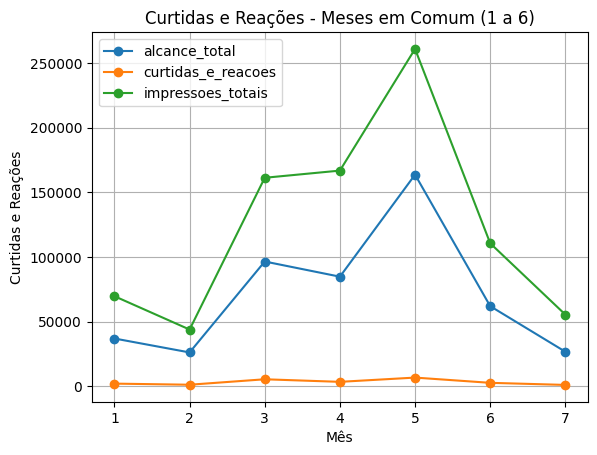

In [22]:


plt.figure(figsize=(8,5))

curtidas_plot = metrica_plot = mes_comum.groupby(['mes'])[["alcance_total", "curtidas_e_reacoes","impressoes_totais"]].sum().plot(label="2027", marker="o")

plt.title("Curtidas e Reações - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Curtidas e Reações")
plt.legend()
plt.grid(True)
plt.show()

Somando os 2 anos, o mês 5 foi o com os melhores números das métricas alcance total e curtidas e reações

Teve uma grande queda no mês 6 em alcance e curtidas e reações

O número de curtidas se manteve em um número mais baixo durante todos meses

Soma dos números de curtidas e reações dos meses em comum entre 2025 e 2026

<Figure size 800x500 with 0 Axes>

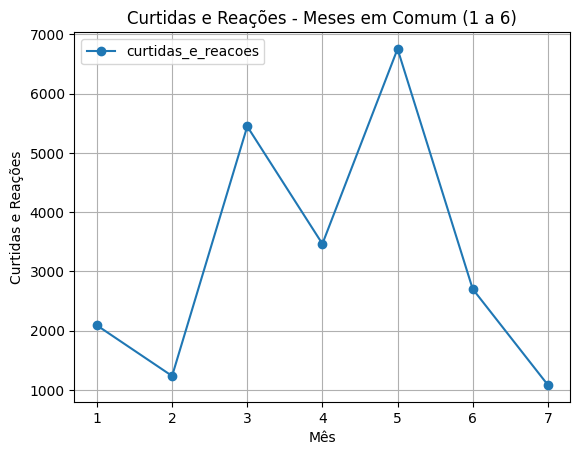

In [23]:

plt.figure(figsize=(8,5))

curtidas_plot = mes_comum.groupby(['mes'])[["curtidas_e_reacoes"]].sum().plot(label="2027", marker="o")

plt.title("Curtidas e Reações - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Curtidas e Reações")
plt.legend()
plt.grid(True)
plt.show()

Para ter uma visão melhor foi feito esse gráfico

O mês 5 também foi o mês com maior número de curtidas e reações

Grande queda no mês 6

Separar os anos para conseguir comparar eles melhor

In [24]:
a25 = df[df['ano'] == 2025]
mes_comum = a25[a25['mes'].isin([1,2,3,4,5,6,7])]
metricas_a25 = mes_comum.groupby('mes')[["alcance_total", "curtidas_e_reacoes","impressoes_totais"]].sum()
metricas_a25

,alcance_total,curtidas_e_reacoes,impressoes_totais
mes,,,
1,25902,1661,53467
2,13655,547,22980
3,42462,2401,74435
4,21295,955,39276
5,58558,2569,97577
6,28551,1147,51165
7,23723,962,51127


In [25]:
a26 = df[df['ano'] == 2026]
mes_comum = a26[a26['mes'].isin([1,2,3,4,5,6,7])]
metricas_a26 = mes_comum.groupby('mes')[["alcance_total", "curtidas_e_reacoes","impressoes_totais"]].sum()
metricas_a26

,alcance_total,curtidas_e_reacoes,impressoes_totais
mes,,,
1,11067,428,16203
2,12543,688,20911
3,54032,3047,86798
4,63472,2510,127507
5,105085,4187,163275
6,33422,1556,59422
7,3024,122,4314


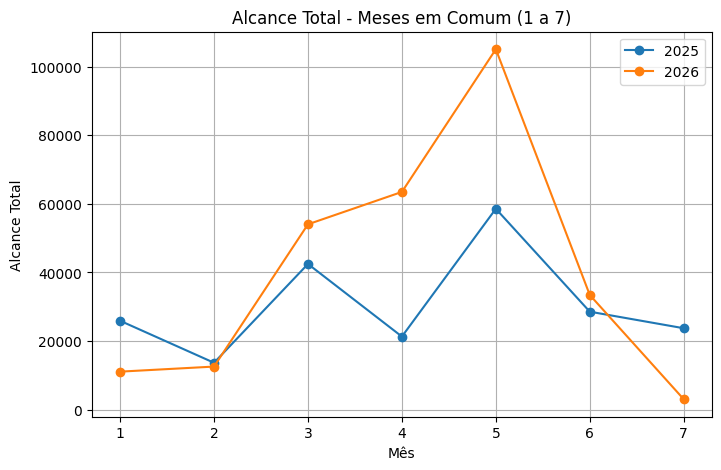

In [26]:

plt.figure(figsize=(8,5))

# Alcance Total
metricas_a25["alcance_total"].plot(label="2025", marker="o")
metricas_a26["alcance_total"].plot(label="2026", marker="o")

plt.title("Alcance Total - Meses em Comum (1 a 7)")
plt.xlabel("Mês")
plt.ylabel("Alcance Total")
plt.legend()
plt.grid(True)
plt.show()

2026 foi um ano melhor do que 2025 nos meses: 3, 4, 5, 6
2025 foi um ano melhor do que 2026 nos meses: 1, 2, 7

O início de 2025 foi melhor que o de 2026 porém os próximos meses de 2026 tiveram uma grande melhora porém no mês 7 de 2026 teve um número muito abaixo

Grande queda do mês 5 para 6 em 2026


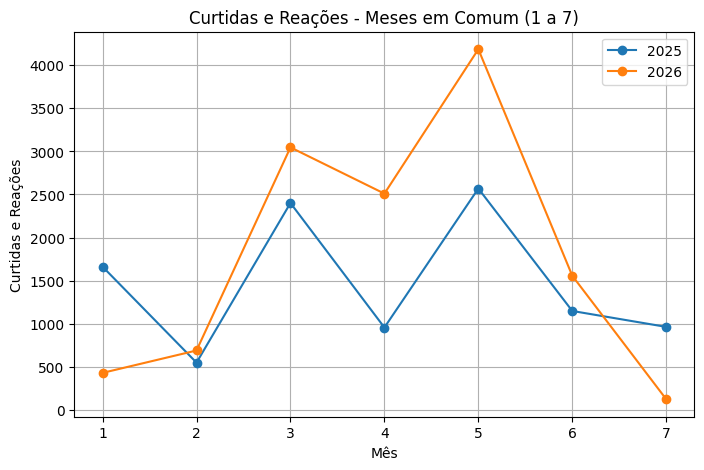

In [27]:

plt.figure(figsize=(8,5))

# Alcance Total
metricas_a25["curtidas_e_reacoes"].plot(label="2025", marker="o")
metricas_a26["curtidas_e_reacoes"].plot(label="2026", marker="o")

plt.title("Curtidas e Reações - Meses em Comum (1 a 7)")
plt.xlabel("Mês")
plt.ylabel("Curtidas e Reações")
plt.legend()
plt.grid(True)
plt.show()

2026 foi um ano melhor do que 2025 nos meses: 2, 3, 4, 5, 6
2025 foi um ano melhor do que 2026 nos meses: 1, 7

O início de 2025 foi melhor que o de 2026 porém os próximos meses de 2026 tiveram uma grande melhora porém no mês 7 de 2026 teve um número muito abaixo

Grande queda do mês 5 para 6 em 2026

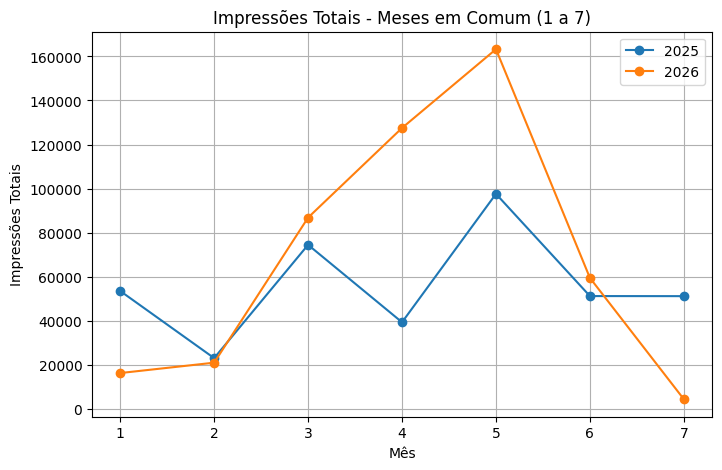

In [28]:

plt.figure(figsize=(8,5))

metricas_a25["impressoes_totais"].plot(label="2025", marker="o")
metricas_a26["impressoes_totais"].plot(label="2026", marker="o")

plt.title("Impressões Totais - Meses em Comum (1 a 7)")
plt.xlabel("Mês")
plt.ylabel("Impressões Totais")
plt.legend()
plt.grid(True)
plt.show()

2026 foi um ano melhor do que 2025 nos meses: 3, 4, 5, 6
2025 foi um ano melhor do que 2026 nos meses: 1, 2, 7

O início de 2025 foi melhor que o de 2026 porém os próximos meses de 2026 tiveram uma grande melhora porém no mês 7 de 2026 teve um número muito abaixo por conta de não ter os dados completos do mês

Grande queda do mês 5 para 6 em 2026


Análise Geral por ano:


O início de 2025 foi melhor que o de 2026 porém os próximos meses de 2026 tiveram uma grande melhora porém no mês 7 de 2026 teve um número muito abaixo(talvez seja falta dos dados do final do mês)

Grande queda do mês 5 para 6 em 2026

2025 foi um ano com bastante altos e baixos porém manteve uma linha sem meses de crescimento ou queda extremos

Visualização do mês 7 sendo incompleto

In [29]:


ultimo_mes = df[(df["ano"] == 2026) & (df["mes"] == 7)]

ultimo_mes["dia"] = ultimo_mes["data_hora_criacao"].dt.date

print(ultimo_mes["dia"].value_counts())

dia
2026-07-03    2
2026-07-02    2
Name: count, dtype: int64


C:\Users\Davi Kunzler Loser\AppData\Local\Temp\ipykernel_2132\1580291427.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ultimo_mes["dia"] = ultimo_mes["data_hora_criacao"].dt.date


Existe um número tão baixo no mês 7 de 2026 porque ele está com os dados incompletos

Então mês 7 vai ser desconsiderado

**Métricas de 2025 e 2026 desconsiderando o mês 7 por falta de dados do ano 2026**

In [30]:
new_a25 = df[df['ano'] == 2025]
new_mes_comum = new_a25[new_a25['mes'].isin([1,2,3,4,5,6])]
new_metricas_a25 = new_mes_comum.groupby('mes')[["alcance_total", "curtidas_e_reacoes","impressoes_totais"]].sum()
new_metricas_a25

,alcance_total,curtidas_e_reacoes,impressoes_totais
mes,,,
1,25902,1661,53467
2,13655,547,22980
3,42462,2401,74435
4,21295,955,39276
5,58558,2569,97577
6,28551,1147,51165


In [31]:
new_a26 = df[df['ano'] == 2026]
new_mes_comum = new_a26[new_a26['mes'].isin([1,2,3,4,5,6])]
new_metricas_a26 = new_mes_comum.groupby('mes')[["alcance_total", "curtidas_e_reacoes","impressoes_totais"]].sum()
new_metricas_a26

,alcance_total,curtidas_e_reacoes,impressoes_totais
mes,,,
1,11067,428,16203
2,12543,688,20911
3,54032,3047,86798
4,63472,2510,127507
5,105085,4187,163275
6,33422,1556,59422


In [32]:
diferença = new_metricas_a26 - new_metricas_a25
diferença

,alcance_total,curtidas_e_reacoes,impressoes_totais
mes,,,
1,-14835,-1233,-37264
2,-1112,141,-2069
3,11570,646,12363
4,42177,1555,88231
5,46527,1618,65698
6,4871,409,8257


In [33]:
a27 = new_metricas_a26 + diferença
a27

,alcance_total,curtidas_e_reacoes,impressoes_totais
mes,,,
1,-3768,-805,-21061
2,11431,829,18842
3,65602,3693,99161
4,105649,4065,215738
5,151612,5805,228973
6,38293,1965,67679


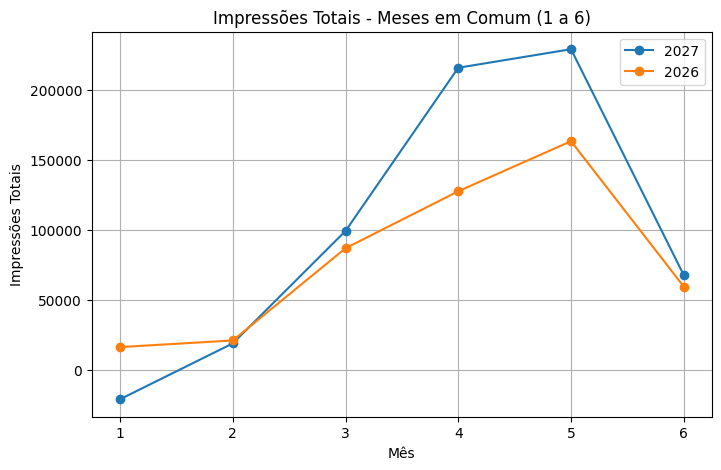

In [34]:

plt.figure(figsize=(8,5))

a27["impressoes_totais"].plot(label="2027", marker="o")
new_metricas_a26["impressoes_totais"].plot(label="2026", marker="o")

plt.title("Impressões Totais - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Impressões Totais")
plt.legend()
plt.grid(True)
plt.show()

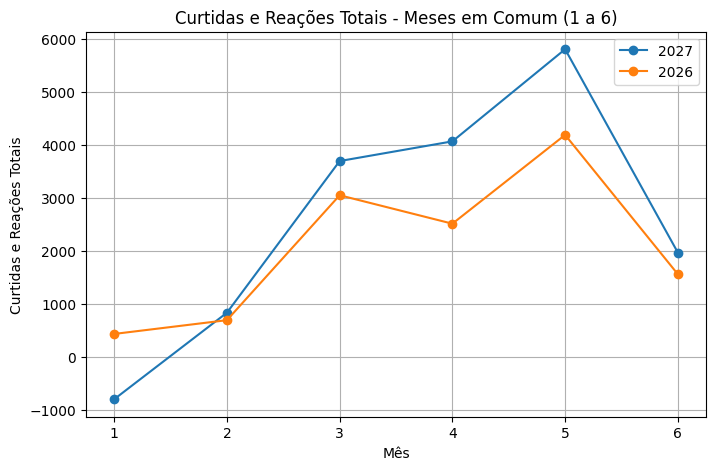

In [35]:

plt.figure(figsize=(8,5))

a27["curtidas_e_reacoes"].plot(label="2027", marker="o")
new_metricas_a26["curtidas_e_reacoes"].plot(label="2026", marker="o")

plt.title("Curtidas e Reações Totais - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Curtidas e Reações Totais")
plt.legend()
plt.grid(True)
plt.show()

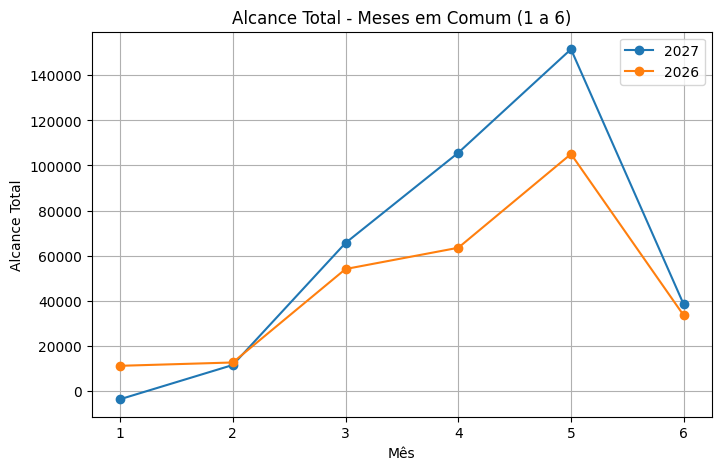

In [36]:

plt.figure(figsize=(8,5))

a27["alcance_total"].plot(label="2027", marker="o")
new_metricas_a26["alcance_total"].plot(label="2026", marker="o")

plt.title("Alcance Total - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Alcance Total")
plt.legend()
plt.grid(True)
plt.show()

Taxa de variação entre os meses em comum de 2025 e 2026

In [37]:
taxa_de_variacao = ((new_metricas_a26 - new_metricas_a25) / new_metricas_a25)
taxa_de_variacao.round(2)

,alcance_total,curtidas_e_reacoes,impressoes_totais
mes,,,
1,-0.57,-0.74,-0.70
2,-0.08,0.26,-0.09
3,0.27,0.27,0.17
4,1.98,1.63,2.25
5,0.79,0.63,0.67
6,0.17,0.36,0.16


Métricas de 2026 para comparar com  a projeção para 2027

In [38]:
new_metricas_a26.round(2)

,alcance_total,curtidas_e_reacoes,impressoes_totais
mes,,,
1,11067,428,16203
2,12543,688,20911
3,54032,3047,86798
4,63472,2510,127507
5,105085,4187,163275
6,33422,1556,59422


Taxa de variação aplicada aos meses em comum de 2026

In [39]:
valor_final = new_metricas_a26 * (1 + taxa_de_variacao)
valor_final.round(2)

,alcance_total,curtidas_e_reacoes,impressoes_totais
mes,,,
1,4728.53,110.29,4910.27
2,11521.56,865.35,19028.28
3,68754.58,3866.81,101214.39
4,189185.01,6596.96,413943.25
5,188579.82,6824.04,273207.06
6,39124.03,2110.84,69011.51


**Gráficos comparando as métricas 2026 e 2027**

Alcance Total (2026-2027)

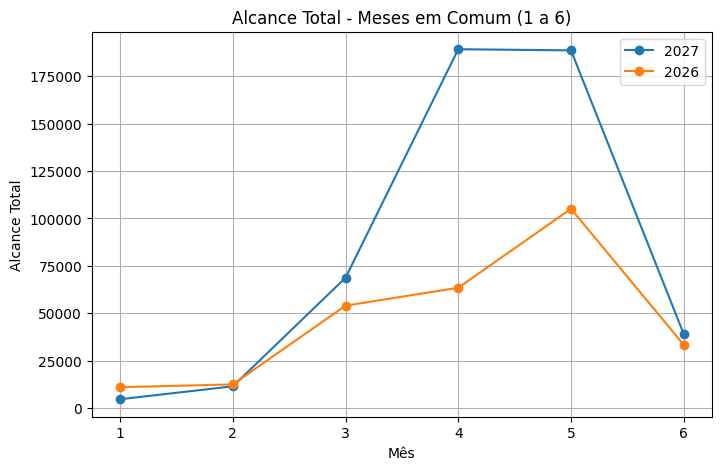

In [40]:

plt.figure(figsize=(8,5))

valor_final["alcance_total"].plot(label="2027", marker="o")
new_metricas_a26["alcance_total"].plot(label="2026", marker="o")

plt.title("Alcance Total - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Alcance Total")
plt.legend()
plt.grid(True)
plt.show()

Curtidas e Reações (2026-2027)

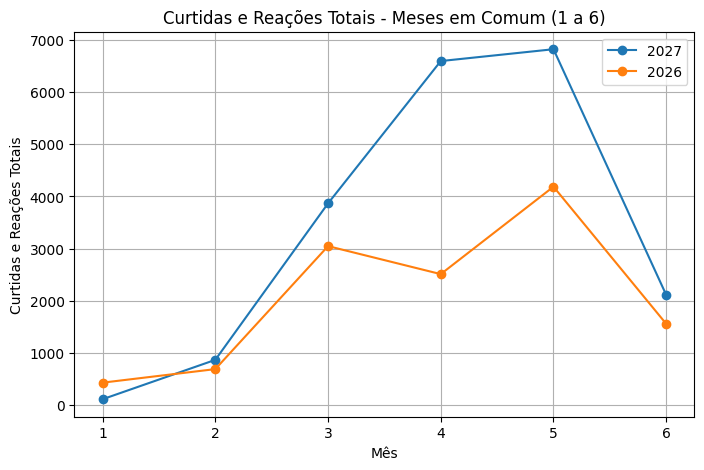

In [41]:

plt.figure(figsize=(8,5))

valor_final["curtidas_e_reacoes"].plot(label="2027", marker="o")
new_metricas_a26["curtidas_e_reacoes"].plot(label="2026", marker="o")

plt.title("Curtidas e Reações Totais - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Curtidas e Reações Totais")
plt.legend()
plt.grid(True)
plt.show()

Impressões Totais (2026-2027)

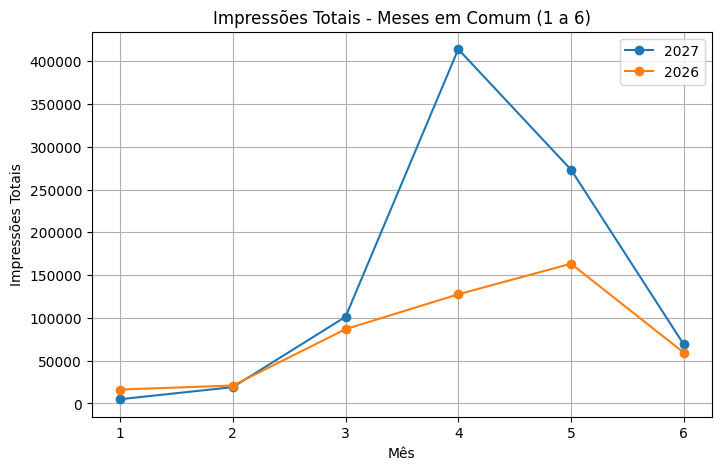

In [42]:

plt.figure(figsize=(8,5))

valor_final["impressoes_totais"].plot(label="2027", marker="o")
new_metricas_a26["impressoes_totais"].plot(label="2026", marker="o")

plt.title("Impressões Totais - Meses em Comum (1 a 6)")
plt.xlabel("Mês")
plt.ylabel("Impressões Totais")
plt.legend()
plt.grid(True)
plt.show()

-----------------------

## Resultado

Análise final

Comparando os anos de 2025 e 2026, foi possível calcular a taxa de variação das métricas considerando os seis meses em comum entre os dois períodos. Inicialmente, os meses correspondentes foram separados e foi calculada a diferença absoluta entre os valores de 2025 e 2026. Entretanto, esse método gerou resultados negativos em alguns casos, o que não era adequado para realizar projeções.

Em seguida, foi utilizada a taxa de variação, calculada pela razão entre a diferença dos valores e o valor inicial, permitindo identificar o crescimento ou a redução relativa de cada métrica. Essa taxa foi então aplicada aos valores de 2026 para projetar os resultados esperados para 2027. Além disso, foi calculado o intervalo de confiança, com o objetivo de estimar a faixa na qual os valores projetados podem se situar, considerando a variabilidade observada nos dados.

Os outliers foram mantidos por conta da possibilidade de terem sido posts que viralizaram


Valor de 2026 sendo aplicada a taxa de variação para simular o valor dos 6 meses de 2027

In [43]:
valor_final.round(2)

,alcance_total,curtidas_e_reacoes,impressoes_totais
mes,,,
1,4728.53,110.29,4910.27
2,11521.56,865.35,19028.28
3,68754.58,3866.81,101214.39
4,189185.01,6596.96,413943.25
5,188579.82,6824.04,273207.06
6,39124.03,2110.84,69011.51


Média da taxa de variação dos 6 meses em comum

In [44]:
taxa_de_variacao.mean().round(2)

alcance_total         0.43
curtidas_e_reacoes    0.40
impressoes_totais     0.41
dtype: float64